<a href="https://colab.research.google.com/github/sanyarajputt/AI-applications-experiments/blob/main/exp4_postmst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import hashlib
import matplotlib.pyplot as plt

In [ ]:
def get_energy_data():
    return {
        "home1": random.randint(20, 100),
        "home2": random.randint(20, 100),
        "home3": random.randint(20, 100),
        "home4": random.randint(20, 100),
        "home5": random.randint(20, 100),
        "home6": random.randint(20, 100)
    }

In [ ]:
def ai_energy_decision(data):
    total = sum(data.values())

    if total > 400:
        return "High Demand - Load Shedding"
    elif total < 180:
        return "Store Excess Energy"
    else:
        return " Balanced Supply"

In [ ]:
blockchain = []

def create_block(data, decision, prev_hash):
    block_string = str(data) + decision + prev_hash
    block_hash = hashlib.sha256(block_string.encode()).hexdigest()

    return {
        "data": data,
        "decision": decision,
        "prev_hash": prev_hash,
        "hash": block_hash
    }

In [ ]:
home1, home2, home3 = [], [], []
decisions = []

prev_hash = "0"

for i in range(15):
    data = get_energy_data()
    decision = ai_energy_decision(data)

    block = create_block(data, decision, prev_hash)
    blockchain.append(block)
    prev_hash = block["hash"]

    home1.append(data["home1"])
    home2.append(data["home2"])
    home3.append(data["home3"])
    decisions.append(decision)

    print(f"\nStep {i+1}")
    print("Energy Data:", data)
    print("AI Decision:", decision)


Step 1
Energy Data: {'home1': 68, 'home2': 99, 'home3': 83, 'home4': 50, 'home5': 59, 'home6': 42}
AI Decision: High Demand - Load Shedding

Step 2
Energy Data: {'home1': 29, 'home2': 71, 'home3': 53, 'home4': 59, 'home5': 40, 'home6': 38}
AI Decision:  Balanced Supply

Step 3
Energy Data: {'home1': 62, 'home2': 60, 'home3': 53, 'home4': 29, 'home5': 21, 'home6': 59}
AI Decision:  Balanced Supply

Step 4
Energy Data: {'home1': 66, 'home2': 67, 'home3': 40, 'home4': 75, 'home5': 71, 'home6': 56}
AI Decision:  Balanced Supply

Step 5
Energy Data: {'home1': 78, 'home2': 38, 'home3': 100, 'home4': 86, 'home5': 25, 'home6': 59}
AI Decision:  Balanced Supply

Step 6
Energy Data: {'home1': 94, 'home2': 88, 'home3': 70, 'home4': 84, 'home5': 78, 'home6': 75}
AI Decision: High Demand - Load Shedding

Step 7
Energy Data: {'home1': 22, 'home2': 35, 'home3': 21, 'home4': 53, 'home5': 69, 'home6': 76}
AI Decision:  Balanced Supply

Step 8
Energy Data: {'home1': 24, 'home2': 92, 'home3': 41, 'home4

/tmp/ipykernel_19923/1443456427.py:22: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


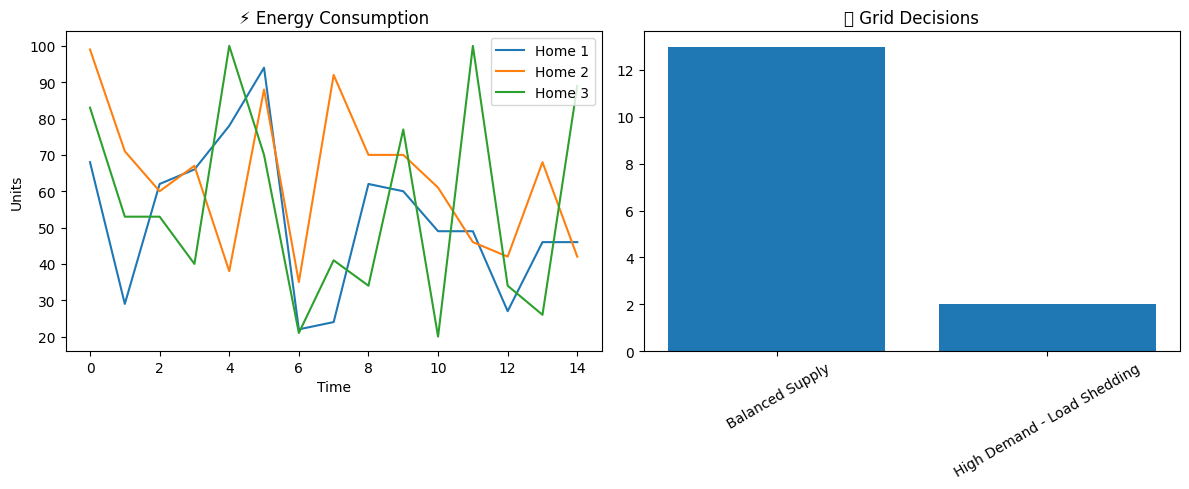

In [ ]:
plt.figure(figsize=(12,5))

# Energy Consumption Graph
plt.subplot(1,2,1)
plt.plot(home1, label="Home 1")
plt.plot(home2, label="Home 2")
plt.plot(home3, label="Home 3")
plt.title("⚡ Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Units")
plt.legend()

# Decision Chart
plt.subplot(1,2,2)
unique = list(set(decisions))
counts = [decisions.count(u) for u in unique]

plt.bar(unique, counts)
plt.title("🤖 Grid Decisions")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()